Configuración inicial y particionado estricto (Prevención de Data Leakage). Para obtener métricas de negocio reales, el modelo debe evaluarse sobre un conjunto de datos completamente ciego. Auditando el entrenamiento original, el modelo de producción se selló en el Fold 4 de la validación cruzada. Replicaremos exactamente el particionado `StratifiedGroupKFold` para aislar el subconjunto Out-Of-Fold (OOF) correspondiente. Esto garantiza que inferiremos únicamente sobre tickets que la red neuronal jamás procesó durante el cálculo de gradientes.

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.model_selection import StratifiedGroupKFold
from pathlib import Path
from tqdm.auto import tqdm
import json

# Rutas de datos y pesos
ROOT_DIR = Path(".").resolve().parent
DATA_PATH = ROOT_DIR / "data" / "gold" / "corpus_sitor_limpio.parquet"
MODEL_PATH = ROOT_DIR / "src" / "models" / "roberta_corporativo"

df = pd.read_parquet(DATA_PATH)

# Replicación estricta del particionado original (Hold-Out ciego)
cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(cv.split(df['full_text'], df['target_tripleta'], groups=df['cluster_id']))
train_idx, val_idx = splits[4]

df_eval = df.iloc[val_idx].copy()
df_eval = df_eval.reset_index(drop=True)

# Instanciación de RoBERTa
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH / "roberta_corporativo_final").to(device)
model.eval()

# Cargar el mapeo real de clases
with open(MODEL_PATH / "label_mapping.json", "r", encoding="utf-8") as f:
    real_id2label = json.load(f)

BATCH_SIZE = 32
textos = df_eval['full_text'].tolist()

predicciones = []
probabilidades_max = []

# ==========================================
# PARÁMETRO DE CALIBRACIÓN TÉRMICA (L-BFGS)
# ==========================================
T_OPT = 1.6139 

with torch.no_grad():
    for i in tqdm(range(0, len(textos), BATCH_SIZE), desc="Inferencia OOF Calibrada"):
        batch = textos[i:i + BATCH_SIZE]
        inputs = tokenizer(batch, padding=True, truncation=True, max_length=256, return_tensors="pt").to(device)
        outputs = model(**inputs)
        
        # Escalado Térmico de los Logits ANTES del Softmax
        logits_calibrados = outputs.logits / T_OPT
        probs = F.softmax(logits_calibrados, dim=1)
        
        max_probs, preds = torch.max(probs, dim=1)
        
        predicciones.extend(preds.cpu().numpy())
        probabilidades_max.extend(max_probs.cpu().numpy())

# Consolidación
df_eval['pred_class_id'] = predicciones
df_eval['confidence'] = probabilidades_max
df_eval['pred_tripleta'] = df_eval['pred_class_id'].map(lambda x: real_id2label.get(str(x), "UNKNOWN"))

accuracy = (df_eval['target_tripleta'] == df_eval['pred_tripleta']).mean()
print(f"\nAccuracy OOF: {accuracy*100:.2f}% (T_opt={T_OPT})")

df_eval[['target_tripleta', 'pred_tripleta', 'confidence']].head()

d:\MasterEvolve\Proyecto TFM\SITOR\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Inferencia OOF Calibrada: 100%|██████████| 97/97 [05:53<00:00,  3.64s/it]


Accuracy OOF: 87.14% (T_opt=1.6139)


,target_tripleta,pred_tripleta,confidence
0,Sales and Pre-Sales_Problem_medium,Sales and Pre-Sales_Problem_medium,0.432402
1,Technical Support_Incident_medium,Technical Support_Incident_medium,0.896694
2,Customer Service_Incident_low,Customer Service_Incident_low,0.760399
3,Customer Service_Change_high,Customer Service_Change_medium,0.688264
4,Technical Support_Incident_high,Technical Support_Incident_high,0.944041


In [2]:
import json

# Cargar el mapeo real de negocio que se exportó en el entrenamiento
map_path = MODEL_PATH / "label_mapping.json"
with open(map_path, "r", encoding="utf-8") as f:
    real_id2label = json.load(f)

# Rehacer el mapeo (los JSON de Python leen las claves como strings)
df_eval['pred_tripleta'] = df_eval['pred_class_id'].map(lambda x: real_id2label.get(str(x), "UNKNOWN"))

# Comprobar la tasa de acierto ciego
accuracy = (df_eval['target_tripleta'] == df_eval['pred_tripleta']).mean()
print(f"Accuracy en el conjunto ciego OOF: {accuracy*100:.2f}%\n")

df_eval[['target_tripleta', 'pred_tripleta', 'confidence']].head()

Accuracy en el conjunto ciego OOF: 87.14%



,target_tripleta,pred_tripleta,confidence
0,Sales and Pre-Sales_Problem_medium,Sales and Pre-Sales_Problem_medium,0.432402
1,Technical Support_Incident_medium,Technical Support_Incident_medium,0.896694
2,Customer Service_Incident_low,Customer Service_Incident_low,0.760399
3,Customer Service_Change_high,Customer Service_Change_medium,0.688264
4,Technical Support_Incident_high,Technical Support_Incident_high,0.944041


Matriz de confusión y rendimiento base. Evaluamos las predicciones del modelo sobre el conjunto ciego Out-Of-Fold. Para garantizar la legibilidad en la presentación ejecutiva, filtramos la matriz para mostrar únicamente las clases principales que concentran el mayor volumen de negocio, excluyendo la categoría de descarte `OUT_OF_SCOPE` para evitar distorsiones visuales en la escala térmica.

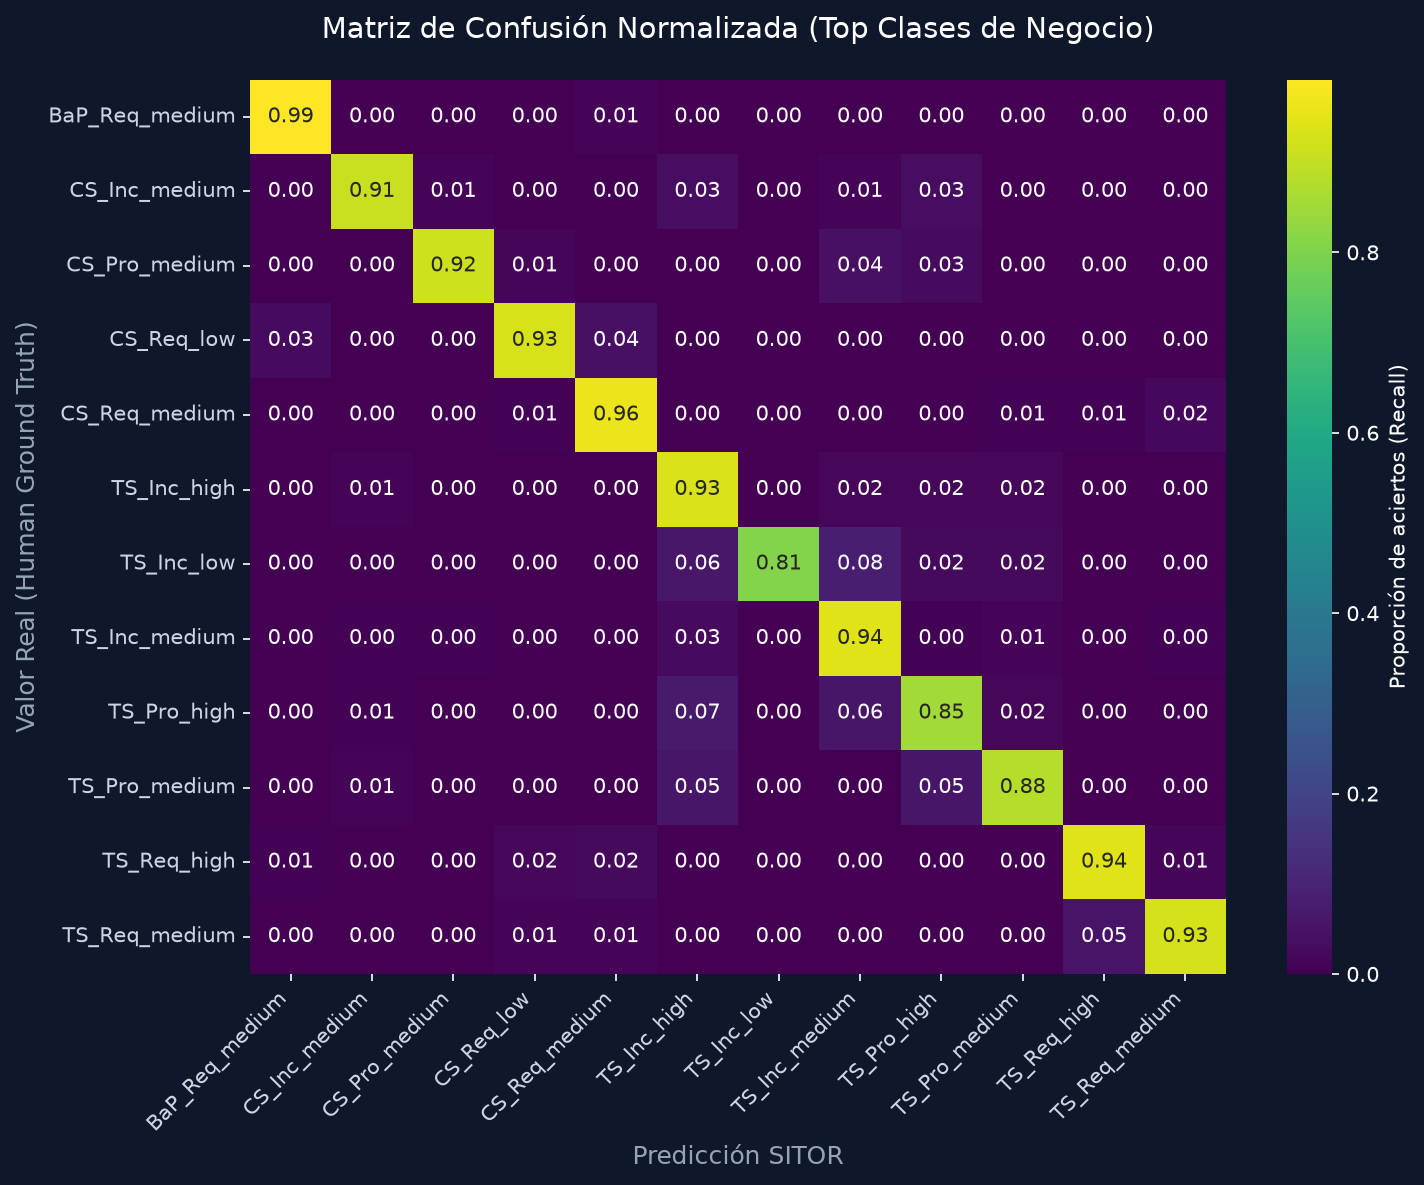

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Filtramos clases de cola larga para que la matriz sea legible (Top 12)
top_classes = df_eval['target_tripleta'].value_counts().head(13).index.tolist()
if "OUT_OF_SCOPE" in top_classes:
    top_classes.remove("OUT_OF_SCOPE")
top_classes = top_classes[:12]

# Subset de la matriz
df_cm = df_eval[df_eval['target_tripleta'].isin(top_classes) & df_eval['pred_tripleta'].isin(top_classes)]

# Compresión de etiquetas (e.g. "Technical Support_Incident_high" -> "TS_Inc_high")
def acortar_etiqueta(etiqueta):
    if etiqueta == "UNKNOWN": return etiqueta
    partes = etiqueta.split('_')
    if len(partes) != 3: return etiqueta
    q_acronimo = "".join([w[0] for w in partes[0].split()])
    t_acronimo = partes[1][:3]
    return f"{q_acronimo}_{t_acronimo}_{partes[2]}"

y_true = df_cm['target_tripleta'].apply(acortar_etiqueta)
y_pred = df_cm['pred_tripleta'].apply(acortar_etiqueta)
etiquetas_unicas = sorted(list(set(y_true.unique().tolist() + y_pred.unique().tolist())))

cm = confusion_matrix(y_true, y_pred, labels=etiquetas_unicas)

# Normalizar sobre las filas (Recall) para ver porcentajes en lugar de conteos absolutos
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
cm_norm = np.nan_to_num(cm_norm)

# Estilo corporativo
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 8), dpi=150)
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=etiquetas_unicas, yticklabels=etiquetas_unicas,
            cbar_kws={'label': 'Proporción de aciertos (Recall)'},
            ax=ax)

ax.set_title("Matriz de Confusión Normalizada (Top Clases de Negocio)", color="white", pad=20, fontsize=14)
ax.set_xlabel("Predicción SITOR", color="#94a3b8", fontsize=12)
ax.set_ylabel("Valor Real (Human Ground Truth)", color="#94a3b8", fontsize=12)
plt.xticks(rotation=45, ha='right', color="#cbd5e1")
plt.yticks(rotation=0, color="#cbd5e1")

plt.tight_layout()
plt.show()

Distribución empírica de confianza. El objetivo analítico de esta gráfica es justificar matemáticamente ante el tribunal por qué fijamos el umbral de pasividad (Threshold) en un valor concreto y no a ojo. Separamos las predicciones correctas de las incorrectas y dibujamos su densidad de probabilidad (Softmax). El punto de divergencia, donde la masa de errores se desploma y los aciertos dominan, nos marca la frontera de fiabilidad operativa.

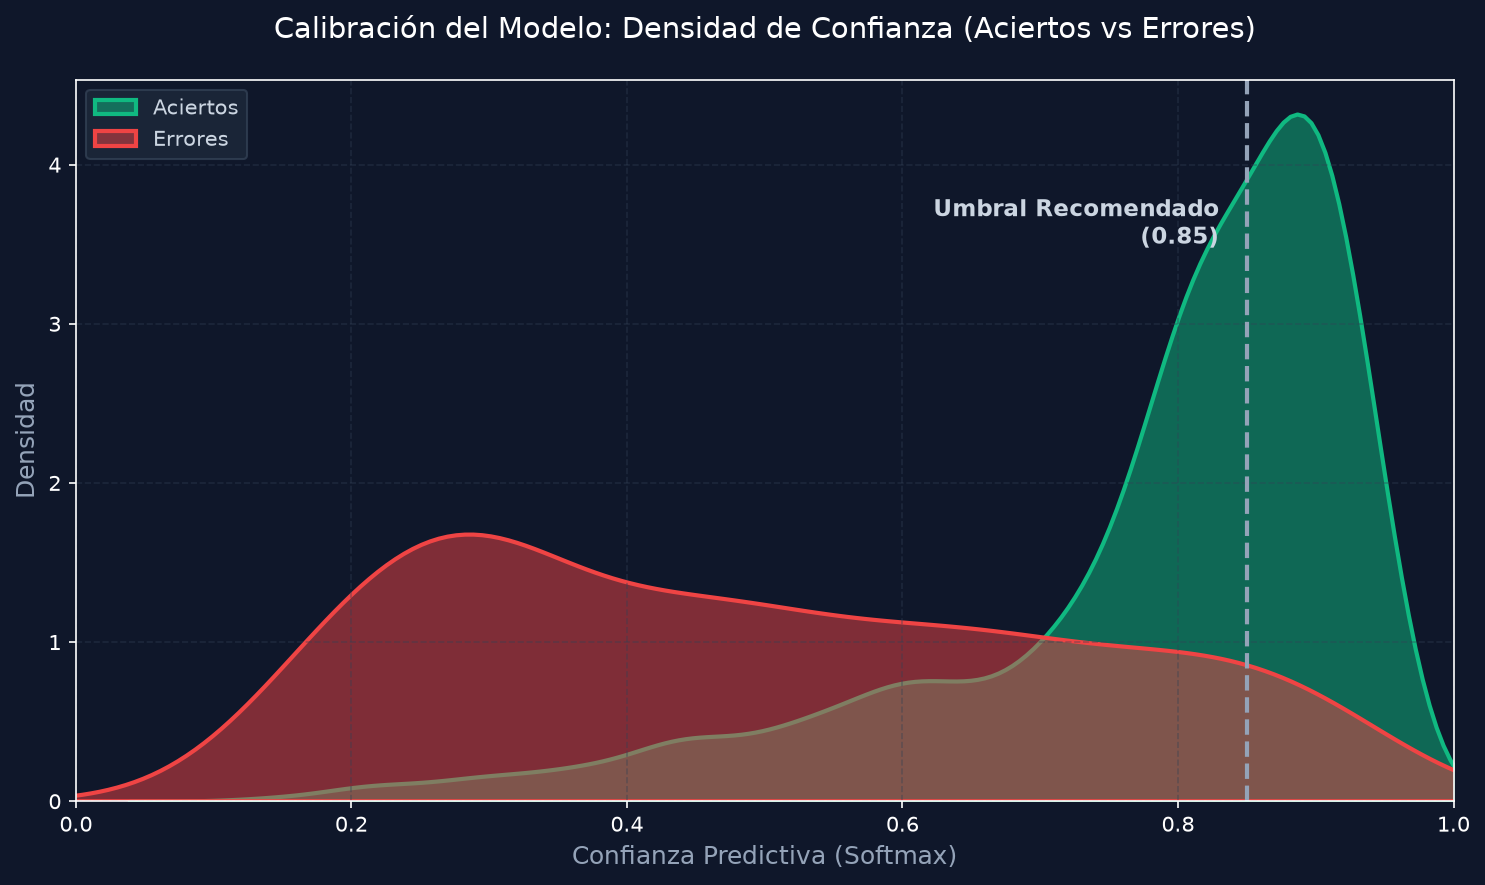

In [4]:
# Etiquetar predicciones correctas vs incorrectas
df_eval['is_correct'] = df_eval['pred_tripleta'] == df_eval['target_tripleta']

# Configuración del lienzo corporativo
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

# Densidad de Aciertos
sns.kdeplot(
    data=df_eval[df_eval['is_correct'] == True], 
    x='confidence', 
    fill=True, 
    color='#10b981', 
    label='Aciertos',
    alpha=0.5,
    linewidth=2,
    ax=ax
)

# Densidad de Errores
sns.kdeplot(
    data=df_eval[df_eval['is_correct'] == False], 
    x='confidence', 
    fill=True, 
    color='#ef4444', 
    label='Errores',
    alpha=0.5,
    linewidth=2,
    ax=ax
)

# Inyectar el umbral de decisión operativo
sweet_spot = 0.85
ax.axvline(sweet_spot, color='#94a3b8', linestyle='--', linewidth=2)
ax.text(sweet_spot - 0.02, ax.get_ylim()[1] * 0.8, f'Umbral Recomendado\n({sweet_spot})', 
        color='#cbd5e1', ha='right', va='center', fontsize=11, fontweight='bold')

ax.set_title("Calibración del Modelo: Densidad de Confianza (Aciertos vs Errores)", color="white", pad=20, fontsize=14)
ax.set_xlabel("Confianza Predictiva (Softmax)", color="#94a3b8", fontsize=12)
ax.set_ylabel("Densidad", color="#94a3b8", fontsize=12)

ax.grid(True, color='#334155', alpha=0.4, linestyle='--')
ax.set_xlim(0, 1.0)

legend = ax.legend(frameon=True, facecolor='#1e293b', edgecolor='#334155')
plt.setp(legend.get_texts(), color='#cbd5e1')

plt.tight_layout()
plt.show()

Impacto del umbral en el error residual frente al operador humano. Esta métrica es el núcleo de la defensa del ROI y la fiabilidad del sistema. Proyecta cómo varía la tasa de error de las decisiones automatizadas a medida que restringimos el umbral de confianza, cruzado con el volumen de tickets que el modelo logra procesar. Las líneas base del error humano (15% en escenario normal y 20% bajo estrés) actúan como referencia estática. El punto de cruce demuestra empíricamente a partir de qué umbral el algoritmo comete menos errores que un empleado del BPO.

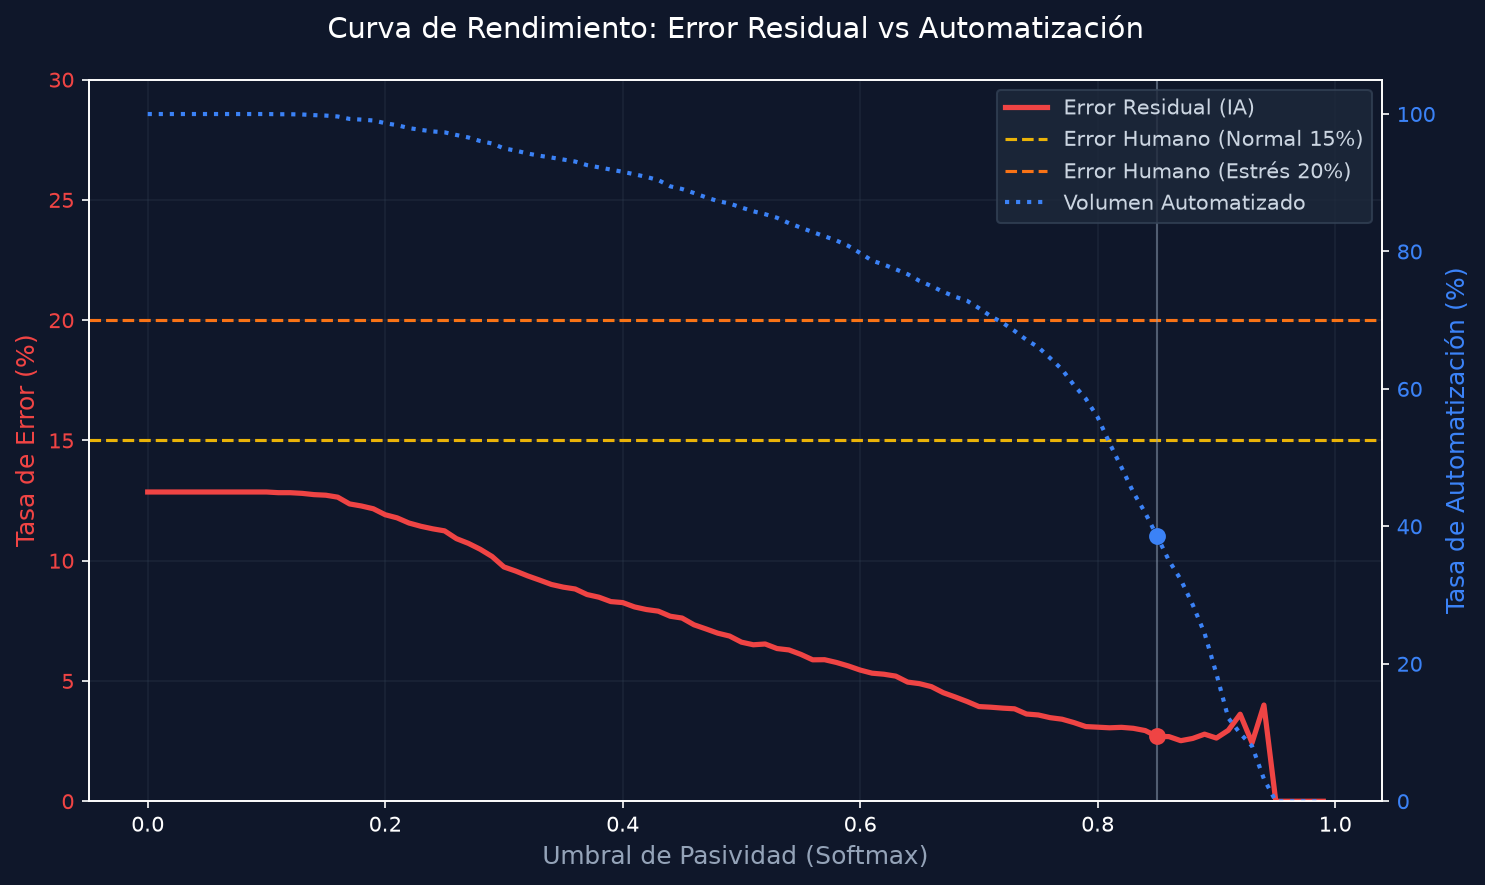

In [5]:
# Barrido continuo del umbral para proyectar las curvas de rendimiento
umbrales = np.arange(0.0, 1.0, 0.01)
automation_rates = []
error_rates = []

for thr in umbrales:
    # Aislamiento de los tickets que superan el umbral (predicciones seguras)
    tickets_automatizados = df_eval[df_eval['confidence'] >= thr]
    vol_auto = len(tickets_automatizados) / len(df_eval)
    automation_rates.append(vol_auto * 100)
    
    # Tasa de error restringida únicamente al pool de tickets automatizados
    if len(tickets_automatizados) > 0:
        errores = len(tickets_automatizados[tickets_automatizados['is_correct'] == False])
        error_rate = errores / len(tickets_automatizados)
        error_rates.append(error_rate * 100)
    else:
        error_rates.append(0)

# Configuración del lienzo corporativo
plt.style.use('dark_background')
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor('#0f172a')
ax1.set_facecolor('#0f172a')

# Eje Y principal: Tasa de Error Residual
ax1.plot(umbrales, error_rates, color='#ef4444', linewidth=2.5, label='Error Residual (IA)')
ax1.set_xlabel("Umbral de Pasividad (Softmax)", color="#94a3b8", fontsize=12)
ax1.set_ylabel("Tasa de Error (%)", color="#ef4444", fontsize=12)
ax1.tick_params(axis='y', labelcolor='#ef4444')
ax1.set_ylim(0, 30)

# Líneas base del error humano del Nivel 1
ax1.axhline(15, color='#eab308', linestyle='--', linewidth=1.5, label='Error Humano (Normal 15%)')
ax1.axhline(20, color='#f97316', linestyle='--', linewidth=1.5, label='Error Humano (Estrés 20%)')

# Eje Y secundario: Tasa de Automatización (Volumen desviado del operador)
ax2 = ax1.twinx()
ax2.plot(umbrales, automation_rates, color='#3b82f6', linewidth=2, linestyle=':', label='Volumen Automatizado')
ax2.set_ylabel("Tasa de Automatización (%)", color="#3b82f6", fontsize=12)
ax2.tick_params(axis='y', labelcolor="#3b82f6")
ax2.set_ylim(0, 105)

# Consolidación de leyendas
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
legend = ax1.legend(lines_1 + lines_2, labels_1 + labels_2, 
                    loc='upper right', frameon=True, facecolor='#1e293b', edgecolor='#334155')
plt.setp(legend.get_texts(), color='#cbd5e1')

# Marcar el sweet spot operativo elegido
sweet_spot = 0.85
ax1.axvline(sweet_spot, color='#94a3b8', linestyle='-', linewidth=1, alpha=0.5)

# Intersecciones para el sweet spot
idx_sweet = int(sweet_spot * 100)
if idx_sweet < len(error_rates):
    err_sweet = error_rates[idx_sweet]
    aut_sweet = automation_rates[idx_sweet]
    ax1.scatter(sweet_spot, err_sweet, color='#ef4444', s=50, zorder=5)
    ax2.scatter(sweet_spot, aut_sweet, color='#3b82f6', s=50, zorder=5)

ax1.set_title("Curva de Rendimiento: Error Residual vs Automatización", color="white", pad=20, fontsize=14)
ax1.grid(True, color='#334155', alpha=0.3)

plt.tight_layout()
plt.show()

Diagrama de flujos de valor operativo (Sankey). Para cerrar la defensa del proyecto ante el negocio, necesitamos mapear el ciclo de vida completo del ticket en producción. Este diagrama modela volumétricamente la partición del tráfico entrante entre la resolución autónoma de la IA y el desvío a revisión manual (asumiendo la métrica base del 15% de error humano). Demuestra visualmente cómo el filtro de pasividad protege el sistema y aísla los falsos positivos de SITOR frente a la cuota de fallos operativos tradicionales.

In [6]:
# Requiere Plotly (pip install plotly)
import plotly.graph_objects as go

# Parámetros operativos del modelo de producción
umbral_operativo = 0.85
error_humano_baseline = 0.15

# Computación de caudales
total_tickets = len(df_eval)
mask_auto = df_eval['confidence'] >= umbral_operativo

df_auto = df_eval[mask_auto]
df_manual = df_eval[~mask_auto]

vol_auto = len(df_auto)
vol_manual = len(df_manual)

aciertos_auto = len(df_auto[df_auto['is_correct'] == True])
errores_auto = len(df_auto[df_auto['is_correct'] == False])

# Proyección del error humano sobre el remanente
errores_manual = int(vol_manual * error_humano_baseline)
aciertos_manual = vol_manual - errores_manual

# Definición del grafo (Nodos)
labels = [
    f"Tickets Entrantes<br>({total_tickets})",
    f"SITOR Automatizado<br>({vol_auto})",
    f"Revisión Manual<br>({vol_manual})",
    f"Acierto IA<br>({aciertos_auto})",
    f"Error IA<br>({errores_auto})",
    f"Acierto Humano<br>({aciertos_manual})",
    f"Error Humano<br>({errores_manual})"
]

# Paleta corporativa alineada con el frontend
color_nodos = ["#94a3b8", "#3b82f6", "#eab308", "#10b981", "#ef4444", "#10b981", "#ef4444"]

# Mapeo topológico de los enlaces (source -> target)
source = [0, 0, 1, 1, 2, 2]
target = [1, 2, 3, 4, 5, 6]
value =  [vol_auto, vol_manual, aciertos_auto, errores_auto, aciertos_manual, errores_manual]
color_links = [
    "rgba(59, 130, 246, 0.4)",  # Caudal Automatizado
    "rgba(234, 179, 8, 0.4)",   # Caudal Desviado
    "rgba(16, 185, 129, 0.4)",  # Aciertos IA
    "rgba(239, 68, 68, 0.4)",   # Errores IA
    "rgba(16, 185, 129, 0.4)",  # Aciertos Humano
    "rgba(239, 68, 68, 0.4)"    # Errores Humano
]

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 25,
      thickness = 20,
      line = dict(color = "black", width = 0.5),
      label = labels,
      color = color_nodos
    ),
    link = dict(
      source = source,
      target = target,
      value = value,
      color = color_links
  )
)])

fig.update_layout(
    title_text="Arquitectura del Flujo Operativo: Desvío y Resolución (Threshold = 0.85)",
    font=dict(size=12, color="white"),
    paper_bgcolor='#0f172a',
    plot_bgcolor='#0f172a',
    margin=dict(t=50, l=25, r=25, b=25)
)

fig.show()

Reducción absoluta de errores operativos (SITOR vs Manual). Esta gráfica materializa el impacto directo del modelo en la calidad del servicio. Comparamos el volumen de errores que cometería un BPO tradicional (asumiendo un 15% de fallo estructural) frente al ecosistema híbrido, donde SITOR filtra y automatiza lo seguro (confianza >= 0.85) y el operador humano solo gestiona el remanente. Explicitamos la caída neta en la tasa de error global.

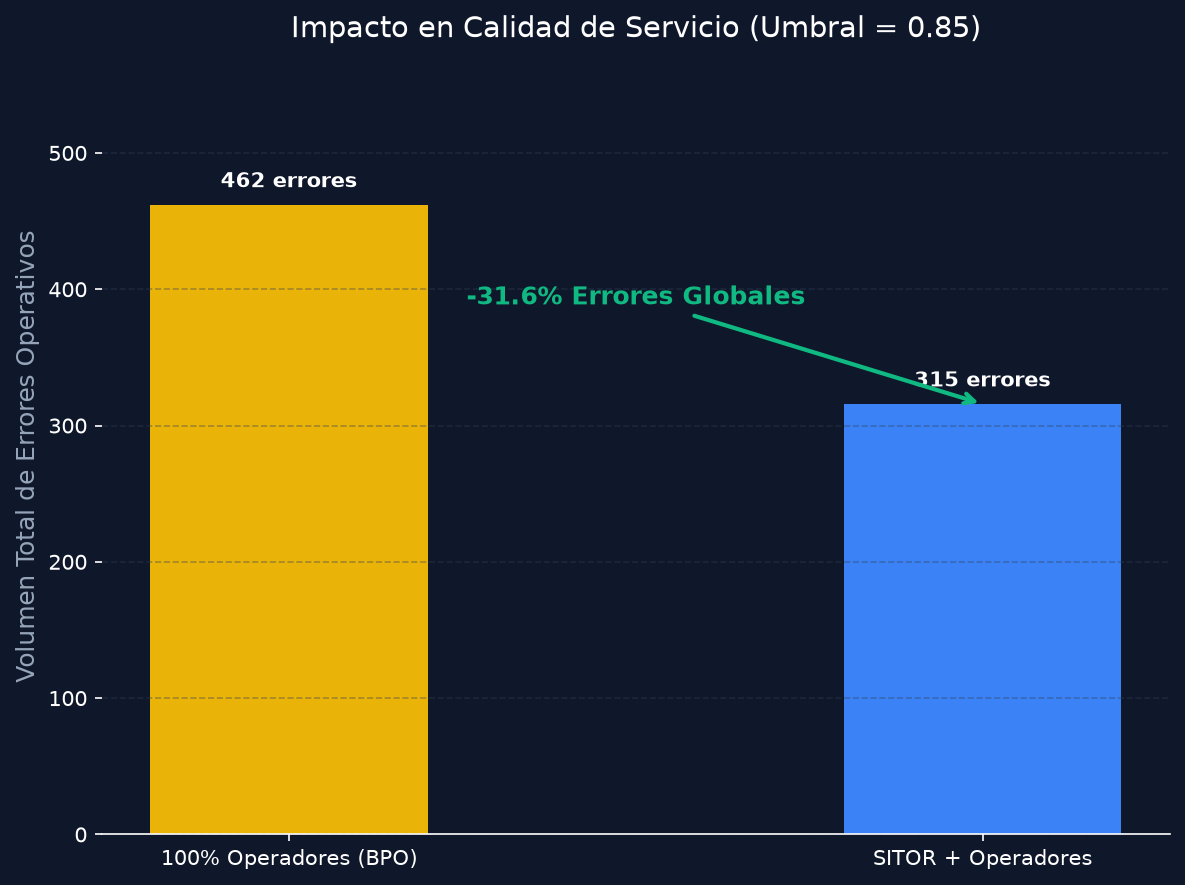

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Parámetros operativos
thr = 0.85
error_baseline = 0.15
total_tickets = len(df_eval)

# Escenario 100% Manual
errores_100_manual = total_tickets * error_baseline

# Escenario Híbrido SITOR (thr=0.85)
mask_auto = df_eval['confidence'] >= thr
df_auto = df_eval[mask_auto]
df_manual = df_eval[~mask_auto]

errores_ia = len(df_auto[df_auto['is_correct'] == False])
errores_rem_manual = len(df_manual) * error_baseline
errores_sitor = errores_ia + errores_rem_manual

mejora_pct = ((errores_100_manual - errores_sitor) / errores_100_manual) * 100

# Lienzo corporativo
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

bars = ax.bar(['100% Operadores (BPO)', 'SITOR + Operadores'], 
              [errores_100_manual, errores_sitor], 
              color=['#eab308', '#3b82f6'],
              width=0.4)

# Inyectar valores absolutos
for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + (errores_100_manual*0.02), 
            f"{int(yval)} errores", ha='center', va='bottom', color='white', fontweight='bold')

# Flecha indicadora de mejora
ax.annotate(f"-{mejora_pct:.1f}% Errores Globales",
            xy=(1, errores_sitor),
            xytext=(0.5, errores_sitor + (errores_100_manual - errores_sitor)/2),
            arrowprops=dict(facecolor='#10b981', edgecolor='#10b981', arrowstyle='->', lw=2),
            fontsize=12, color='#10b981', fontweight='bold', ha='center')

ax.set_title(f"Impacto en Calidad de Servicio (Umbral = {thr})", color="white", pad=20, fontsize=14)
ax.set_ylabel("Volumen Total de Errores Operativos", color="#94a3b8", fontsize=12)
ax.grid(axis='y', color='#334155', alpha=0.4, linestyle='--')
ax.set_ylim(0, errores_100_manual * 1.2)

# Ocultar bordes no críticos
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

Cálculo empírico del umbral de pasividad por tolerancia operativa. Agrupamos el volumen de tickets en deciles de confianza para evaluar su tasa de error marginal real. La intersección de la curva de fallos de la IA con la línea base de ineficiencia del operador humano define matemáticamente la frontera operativa: 0.85 para un escenario normal (15% error humano) y 0.80 para escenarios de estrés por alta volumetría (20% error humano).

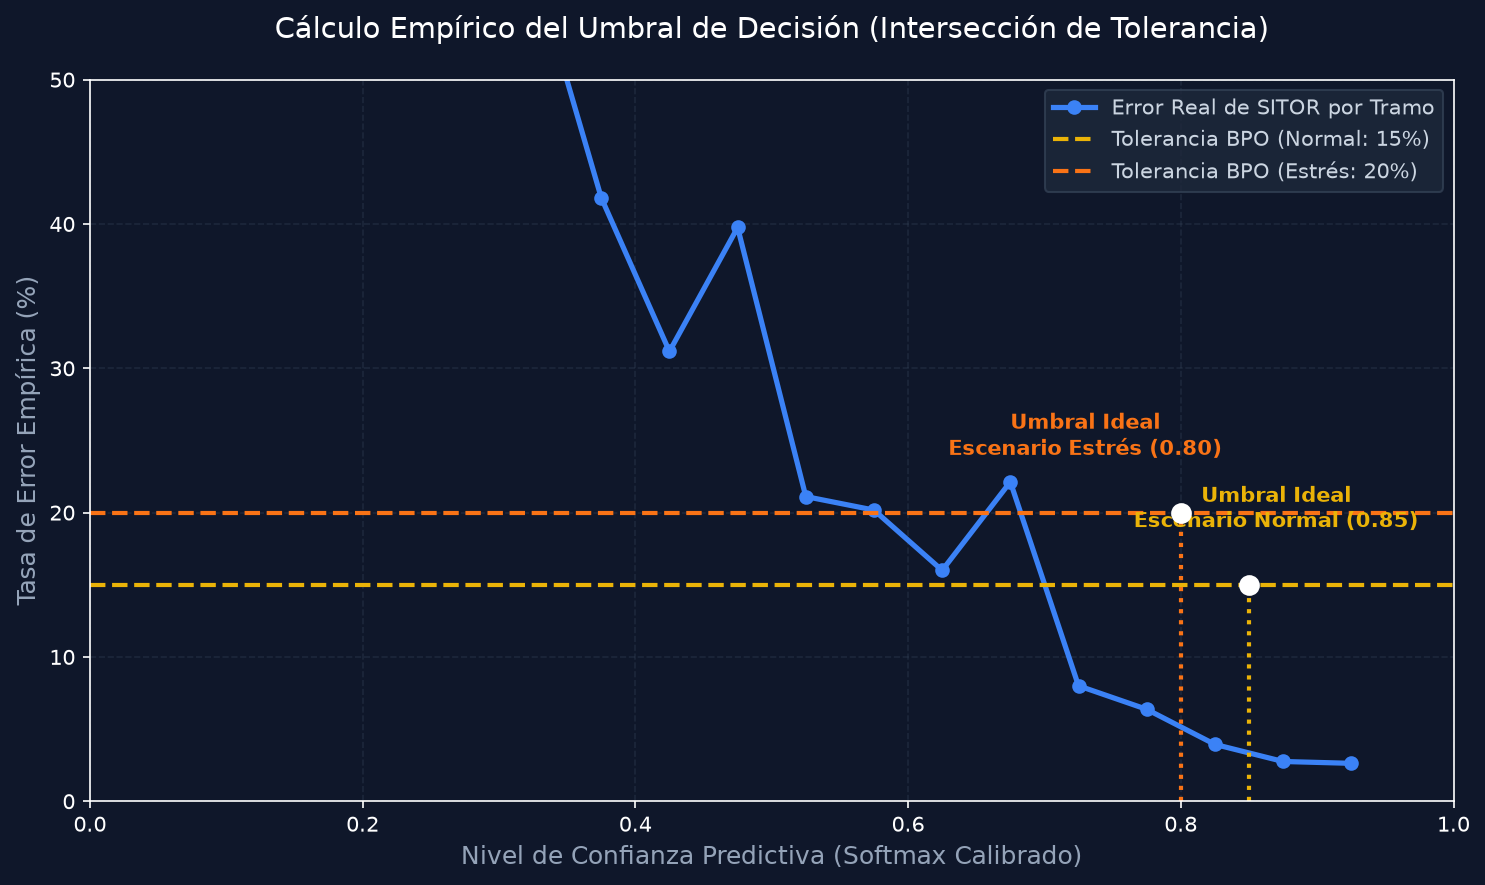

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Segmentación en rangos (bins) de confianza 
bins = np.arange(0.0, 1.05, 0.05)
bin_centers = bins[:-1] + 0.025
error_marginal = []

# Calcular la tasa empírica de error para cada nivel de confianza
for i in range(len(bins)-1):
    mask = (df_eval['confidence'] >= bins[i]) & (df_eval['confidence'] < bins[i+1])
    subset = df_eval[mask]
    
    # Exigir un mínimo de tickets en el bin para que tenga validez estadística
    if len(subset) > 5: 
        err = len(subset[subset['is_correct'] == False]) / len(subset)
        error_marginal.append(err * 100)
    else:
        error_marginal.append(np.nan)

# Configuración del lienzo corporativo
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

# Curva empírica de error de SITOR
ax.plot(bin_centers, error_marginal, color='#3b82f6', marker='o', 
        markersize=6, linewidth=2.5, label='Error Real de SITOR por Tramo')

# Inyección de las tolerancias de negocio (Líneas base)
ax.axhline(15, color='#eab308', linestyle='--', linewidth=2, label='Tolerancia BPO (Normal: 15%)')
ax.axhline(20, color='#f97316', linestyle='--', linewidth=2, label='Tolerancia BPO (Estrés: 20%)')

# Proyecciones teóricas de intersección
ax.axvline(0.85, ymax=15/50, color='#eab308', linestyle=':', linewidth=2)
ax.axvline(0.80, ymax=20/50, color='#f97316', linestyle=':', linewidth=2)

# Resaltar los nodos de intersección (Umbrales Ideales)
ax.scatter([0.85, 0.80], [15, 20], color='white', s=80, zorder=5)

ax.annotate("Umbral Ideal\nEscenario Normal (0.85)", xy=(0.85, 15), 
            xytext=(0.85 + 0.02, 15 + 4), color='#eab308', 
            fontweight='bold', fontsize=10, ha='center')

ax.annotate("Umbral Ideal\nEscenario Estrés (0.80)", xy=(0.80, 20), 
            xytext=(0.80 - 0.07, 20 + 4), color='#f97316', 
            fontweight='bold', fontsize=10, ha='center')

# Formateo y limpieza
ax.set_title("Cálculo Empírico del Umbral de Decisión (Intersección de Tolerancia)", color="white", pad=20, fontsize=14)
ax.set_xlabel("Nivel de Confianza Predictiva (Softmax Calibrado)", color="#94a3b8", fontsize=12)
ax.set_ylabel("Tasa de Error Empírica (%)", color="#94a3b8", fontsize=12)

ax.grid(True, color='#334155', alpha=0.4, linestyle='--')
# Ajustar el límite Y para ver con claridad la zona de los cruces (0 - 50%)
ax.set_ylim(0, 50) 
ax.set_xlim(0, 1.0)

legend = ax.legend(frameon=True, facecolor='#1e293b', edgecolor='#334155', loc='upper right')
plt.setp(legend.get_texts(), color='#cbd5e1')

plt.tight_layout()
plt.show()